In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import prince
import statsmodels.api as sm
import statsmodels.formula.api as smf
import itertools
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 09/18/26 12:37:49


In [42]:
#loading the training data
file_path_train = "fraudTrain.csv"

fraud_train = pd.read_csv(file_path_train)

fraud_train.rename(columns={fraud_train.columns[0]: "id"}, inplace=True)

fraud_train = fraud_train.set_index(fraud_train.columns[0])


In [43]:
#Loading the tesing data
file_path_valid = "fraudTest.csv"

fraud_valid = pd.read_csv(file_path_valid)

fraud_valid.rename(columns={fraud_valid.columns[0]: "id"}, inplace=True)

fraud_valid = fraud_valid.set_index(fraud_valid.columns[0])

In [44]:
#Loading the tesing data
file_path_pop = "Census_State_Pop_Ttls_2020-2025.csv"

us_pop = pd.read_csv(file_path_pop)

#fraud_valid.rename(columns={fraud_valid.columns[0]: "id"}, inplace=True)

#fraud_valid = fraud_valid.set_index(fraud_valid.columns[0])

In [46]:
#Loading pop data

us_pop.dtypes
len(us_pop["NAME"].unique())
us_pop["NAME"].unique()
print(us_pop.columns.tolist())

state = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY'
}

us_pop['state'] = us_pop['NAME'].map(state_abbreviations)
us_pop['state'].unique()

us_pop.loc[us_pop['state'] == 'NY', 'POPESTIMATE2025'] #Checked with a google search and it's correct.


['SUMLEV', 'REGION', 'DIVISION', 'STATE', 'NAME', 'ESTIMATESBASE2020', 'POPESTIMATE2020', 'POPESTIMATE2021', 'POPESTIMATE2022', 'POPESTIMATE2023', 'POPESTIMATE2024', 'POPESTIMATE2025', 'NPOPCHG_2020', 'NPOPCHG_2021', 'NPOPCHG_2022', 'NPOPCHG_2023', 'NPOPCHG_2024', 'NPOPCHG_2025', 'BIRTHS2020', 'BIRTHS2021', 'BIRTHS2022', 'BIRTHS2023', 'BIRTHS2024', 'BIRTHS2025', 'DEATHS2020', 'DEATHS2021', 'DEATHS2022', 'DEATHS2023', 'DEATHS2024', 'DEATHS2025', 'NATURALCHG2020', 'NATURALCHG2021', 'NATURALCHG2022', 'NATURALCHG2023', 'NATURALCHG2024', 'NATURALCHG2025', 'INTERNATIONALMIG2020', 'INTERNATIONALMIG2021', 'INTERNATIONALMIG2022', 'INTERNATIONALMIG2023', 'INTERNATIONALMIG2024', 'INTERNATIONALMIG2025', 'DOMESTICMIG2020', 'DOMESTICMIG2021', 'DOMESTICMIG2022', 'DOMESTICMIG2023', 'DOMESTICMIG2024', 'DOMESTICMIG2025', 'NETMIG2020', 'NETMIG2021', 'NETMIG2022', 'NETMIG2023', 'NETMIG2024', 'NETMIG2025', 'RESIDUAL2020', 'RESIDUAL2021', 'RESIDUAL2022', 'RESIDUAL2023', 'RESIDUAL2024', 'RESIDUAL2025', 'GQES

46    20002427
Name: POPESTIMATE2025, dtype: int64

In [47]:
#Creating a population col on the state level by combining the pop's of the cities
#Honestly not sure if this is a good way of doing it, might be better off grabbing a diff data set and merging it in
city_pop = (
    fraud_train[["city", "state", "city_pop"]]
    .drop_duplicates()
)


fraud_train = fraud_train.merge(
    us_pop[['state', 'POPESTIMATE2025']],
    on='state',
    how='left'
)

print(fraud_train.loc[fraud_train['state'] == 'PA', 'POPESTIMATE2025']) # just making sure it added correctly.

####################################################################################

# making a birth year col
today = pd.Timestamp.today()
fraud_train["dob"] = pd.to_datetime(fraud_train["dob"])

#fraud_train["birth_year"] = fraud_train["dob"].astype(str).str[:4].astype(int)

#Giving the aprox age of all people
fraud_train["age"] = today.year - fraud_train["dob"].dt.year
#print(fraud_train["birth_year"].head())
print(fraud_train["age"].head())

##################################################################################
age_bins = [20, 30, 40, 50, 60, 70, 80, 90, float("inf")]

age_labels = [
    "21-30",
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "71-80",
    "81-90",
    "91+"
]

fraud_train["age_group"] = pd.cut(
    fraud_train["age"],
    bins=age_bins,
    labels=age_labels
)

############################################################################



0    38
1    48
2    64
3    59
4    40
Name: age, dtype: int64


(1296675, 25)

In [48]:
#Training and validation split
training_data, testing_data = train_test_split(fraud_train, test_size=0.2, random_state=1376)

print("Training set shape:")
print(training_data.shape)
print("Testing set shape:")
print(testing_data.shape) 

Training set shape:
(1037340, 25)
Testing set shape:
(259335, 25)


In [49]:
training_data.dtypes

trans_date_trans_time            object
cc_num                            int64
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
gender                           object
street                           object
city                             object
state                            object
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                      datetime64[ns]
trans_num                        object
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
POPESTIMATE2025                 float64
age                               int64
age_group                      category


In [57]:
#freq table for cat with % 
for col in training_data.select_dtypes(include=["object", "category", "int64"]).columns:
    
    freq = training_data[col].value_counts(dropna=False)
    percent = training_data[col].value_counts(normalize=True, dropna=False) * 100
    
    table = pd.DataFrame({
        "Frequency": freq,
        "Percent": percent
    })
    
    print(f"\n{col}")
    print(table)


trans_date_trans_time
                       Frequency   Percent
trans_date_trans_time                     
2020-06-01 01:37:47            4  0.000386
2019-12-11 16:01:10            3  0.000289
2019-12-15 15:39:34            3  0.000289
2019-12-29 16:28:32            3  0.000289
2020-03-30 23:35:21            3  0.000289
...                          ...       ...
2019-07-16 20:40:55            1  0.000096
2019-04-22 09:21:28            1  0.000096
2019-02-26 17:20:30            1  0.000096
2019-12-15 20:28:20            1  0.000096
2019-11-26 13:02:23            1  0.000096

[1023316 rows x 2 columns]

cc_num
                     Frequency   Percent
cc_num                                  
6534628260579800          2519  0.242833
36722699017270            2516  0.242543
6011367958204270          2510  0.241965
571365235126              2500  0.241001
4512828414983801773       2495  0.240519
...                        ...       ...
501894933032                 5  0.000482
4157213332670

In [50]:
#just a look at cols
print("Number of unique cities:")
print(training_data["city"].nunique())
print("Number of unique zip codes:")
print(training_data["zip"].nunique())
print("Number of unique merchants:")
print(training_data["merchant"].nunique())
print("Number of unique purchase catagories:")
print(training_data["category"].nunique())
print("Unique purchase catagories:")
print(training_data["category"].unique())

print("Number of included states:")
print(training_data["state"].nunique())
print("list of states:")
print(training_data["state"].unique())
print("51 states because Washington DC is included")

print("Min transaction ammount:")
print(training_data["amt"].min())
print("Mean transaction ammount:")
print(training_data["amt"].mean())
print("Median transaction ammount:")
print(training_data["amt"].median())
print("Max transaction ammount:")
print(training_data["amt"].max())

print("Min age:")
print(training_data["age"].min())
print("Mean age:")
print(training_data["age"].mean())
print("Median age:")
print(training_data["age"].median())
print("Most freq age:")
print(training_data["age"].mode())
print("Max age:")
print(training_data["age"].max())

print("Number of frauds:")
print(training_data["is_fraud"].value_counts())
print("Ratio of frauds in %:")
print((6039/(6039 + 1031301))*100)
print("It looks like less than 1% of the total transactions are fraudulent")
print("Number of frauds in testing set:")
print(testing_data["is_fraud"].value_counts())
print("Testing ratio of frauds in %:")
print((1467/(1467 + 257868))*100)
print("Just wanting to make sure the testing set reflects the training set, and it does")



Number of unique cities:
894
Number of unique zip codes:
970
Number of unique merchants:
693
Number of unique purchase catagories:
14
Unique purchase catagories:
['kids_pets' 'gas_transport' 'grocery_net' 'home' 'food_dining' 'misc_pos'
 'misc_net' 'travel' 'shopping_net' 'grocery_pos' 'shopping_pos'
 'entertainment' 'personal_care' 'health_fitness']
Number of included states:
51
list of states:
['WA' 'LA' 'NY' 'SC' 'MA' 'PA' 'NJ' 'WI' 'MN' 'MI' 'AR' 'OR' 'TX' 'AL'
 'MO' 'IN' 'NV' 'OH' 'FL' 'ME' 'MD' 'NE' 'NM' 'KY' 'KS' 'VT' 'NH' 'IL'
 'NC' 'AZ' 'IA' 'SD' 'DC' 'GA' 'MS' 'OK' 'VA' 'ND' 'WY' 'CA' 'UT' 'MT'
 'WV' 'CO' 'CT' 'TN' 'ID' 'HI' 'AK' 'RI' 'DE']
51 states because Washington DC is included
Min transaction ammount:
1.0
Mean transaction ammount:
70.34589298590626
Median transaction ammount:
47.53
Max transaction ammount:
28948.9
Min age:
21
Mean age:
52.733546378236646
Median age:
51.0
Most freq age:
0    54
Name: age, dtype: int64
Max age:
102
Number of frauds:
is_fraud
0    1031301

count    1.037340e+06
mean     5.273355e+01
std      1.737789e+01
min      2.100000e+01
25%      3.900000e+01
50%      5.100000e+01
75%      6.400000e+01
max      1.020000e+02
Name: age, dtype: float64
Age frequency table:
age
21      1548
22      5990
23      3142
25      4441
26      7573
27     15037
28     10631
29     23820
30      4827
31     16477
32     16118
33     23431
34     12299
35     19664
36     25084
37     19970
38     24676
39     29920
40     25606
41     29904
42     32101
43     20212
44     16456
45     15994
46     21677
47     14310
48     24480
49     20135
50     26198
51     24259
52     27579
53     25104
54     36195
55     21947
56     20659
57     16304
58     13487
59     18077
60     18851
61     14747
62     12804
63     10603
64     18450
65     13710
66     14033
67     12314
68     10777
69      9402
70     13556
71     15635
72     12730
73      8583
74      8665
75      7711
76      8534
77      7719
78      7812
79      2456
80      7347
81    

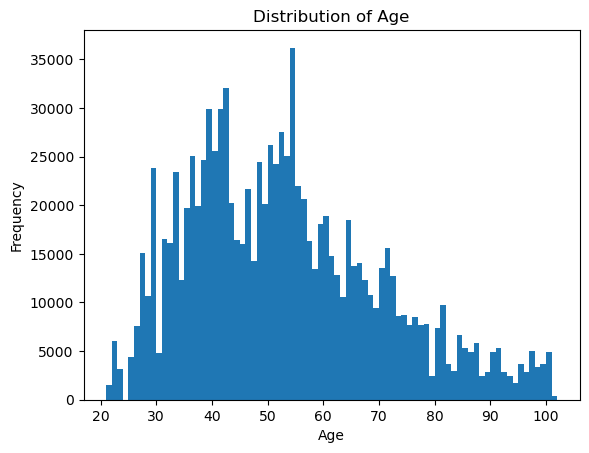

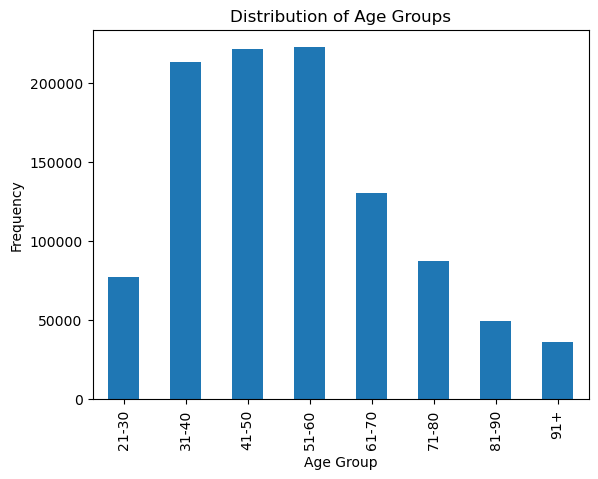

In [58]:
#Looking at age
pd.set_option("display.max_rows", 100)
print(training_data["age"].describe())
print("Age frequency table:")
print(training_data["age"].value_counts().sort_index())

print("Age Group frequency table:")
print(training_data["age_group"].value_counts().sort_index())


plt.hist(training_data["age"], bins=81)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()

######################################################

training_data["age_group"].value_counts().reindex(age_labels).plot(kind="bar")

plt.xlabel("Age Group")
plt.ylabel("Frequency")
plt.title("Distribution of Age Groups")
#plt.xticks(rotation=45)

plt.show()




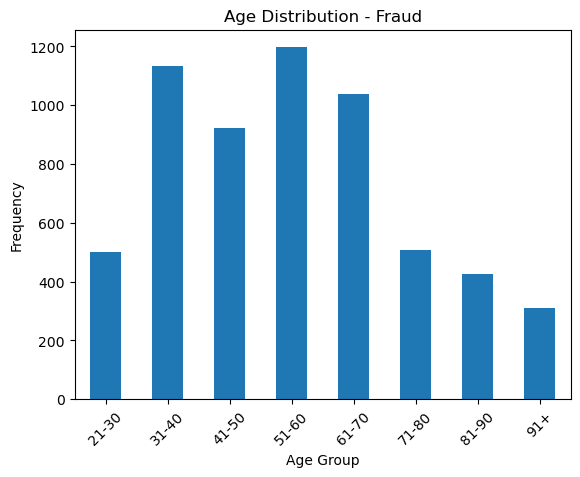

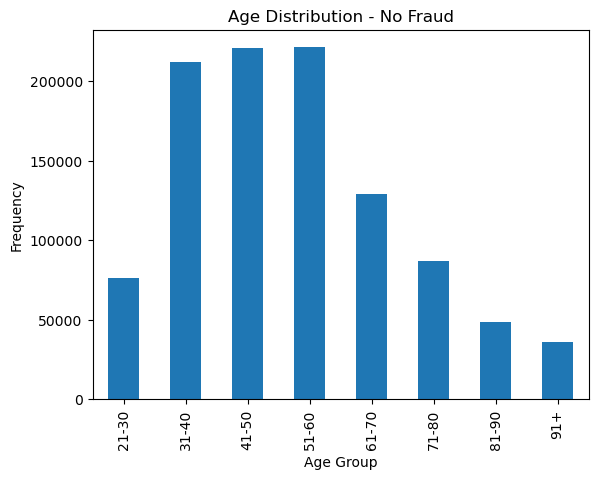

In [52]:
fraud = training_data[training_data["is_fraud"] == 1]

fraud["age_group"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Age Group")
plt.ylabel("Frequency")
plt.title("Age Distribution - Fraud")
plt.xticks(rotation=45)

plt.show()

#############################################################

fraud_no = training_data[training_data["is_fraud"] == 0]

fraud_no["age_group"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Age Group")
plt.ylabel("Frequency")
plt.title("Age Distribution - No Fraud")
#plt.xticks(rotation=45)

plt.show()
